# ISTVT — Interpretable Spatial-Temporal Video Transformer for Deepfake Detection
### Reproduction on Celeb-DF-v2 (balanced 590 real / 590 fake), Google Colab, T4 GPU

This notebook implements **only the method introduced in the paper** (ISTVT: decomposed
spatial-temporal self-attention + self-subtract mechanism), as per the assignment instructions.
Baselines from the paper (VTN, VidTr, ViViT, STIL, FTCN, etc.) are intentionally **not**
re-implemented.

**Key features, given a fixed, small dataset (590+590 videos):**

1. **Face cropping is added.** The paper detects/aligns faces with MTCNN and crops to the face region before doing anything else (Sec. IV-B.1). A previous attempt skipped this and fed full video frames to the model — the model was mostly looking at background/lighting, not facial forgery artifacts, which is consistent with AUC stuck at 0.5.
2. **Consecutive-frame sampling, not frames spread across the whole clip.** The paper trains on "sequences that consist of 6 continuous facial images," with the self-subtract mechanism built to catch *frame-to-frame* (short-term) inconsistency
3. **Pretrained backbone instead of a from-scratch CNN.** With ~944 training videos, learning good low-level forgery-texture features from random initialization is unrealistic. We use a small pretrained CNN (ImageNet-pretrained, via `timm`) as the texture feature extractor in place of the paper's from-scratch Xception entry flow, and fine-tune it at a low learning rate. This is a transfer-learning substitution for the paper's CNN — the **transformer architecture itself (decomposed spatial-temporal attention + self-subtract) is implemented exactly as in the paper**, which is the actual contribution we're asked to reproduce.
4. **Multiple overlapping 6-frame clips per video** instead of one clip per video, to multiply the number of training examples from a fixed pool of videos
5. **Learning rate scaled for transfer learning, with warmup.** The paper trains *from scratch* at lr=5e-4 for up to 100 epochs on 4 GPUs. We are fine-tuning a partially-pretrained model on far less data/compute, so we use a smaller, layer-wise learning rate (backbone vs. transformer head) with a brief warmup — too high an lr will explode the pretrained features, too low (as in the previous 2e-5 attempt) means the transformer head barely leaves its random initialization in a handful of epochs.
6. **Video-level train/val split.** All clips from one video stay in one split, so the model is never validated on a video it has already seen frames from.

## Step 1 — Mount Kaggle credentials and download Celeb-DF-v2 directly into Colab

This uploads our `kaggle.json` (not the 10GB dataset) and pulls the dataset straight onto Colab's VM disk — nothing is downloaded onto the PC.

In [ ]:
# ===================== Kaggle credential upload + dataset download =====================
import os
from google.colab import files

os.makedirs("/root/.kaggle", exist_ok=True)

if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please select your kaggle.json file (Kaggle -> Account -> Create New API Token)")
    uploaded = files.upload()
    assert "kaggle.json" in uploaded, "You must upload a file named kaggle.json"
    with open("/root/.kaggle/kaggle.json", "wb") as f:
        f.write(uploaded["kaggle.json"])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install -q kaggle

DATA_ROOT = "/content/celeb-df-v2"
if not os.path.exists(DATA_ROOT):
    os.makedirs(DATA_ROOT, exist_ok=True)
    print("Downloading Celeb-DF-v2 from Kaggle (this happens entirely on the Colab VM)...")
    !kaggle datasets download -d reubensuju/celeb-df-v2 -p /content --force
    print("Unzipping...")
    !unzip -q /content/celeb-df-v2.zip -d {DATA_ROOT}
    print("Done.")
else:
    print("Dataset already present at", DATA_ROOT)

# Sanity check folder layout
for root, dirs, _ in os.walk(DATA_ROOT):
    for d in dirs:
        print(os.path.join(root, d))
    break

Dataset already present at /content/celeb-df-v2
/content/celeb-df-v2/Celeb-synthesis
/content/celeb-df-v2/Celeb-real
/content/celeb-df-v2/YouTube-real


## Step 2 — Install remaining dependencies

`timm` gives us a pretrained CNN backbone to substitute for the paper's from-scratch Xception
entry flow (see notebook intro, point 3). We use OpenCV's built-in DNN face detector for face
cropping (see Step 4) instead of a separate face-detection package.

**Root cause of the repeated `numpy`/`torch` errors in earlier attempts, now fixed:**
the `facenet-pytorch` package (previously used here for MTCNN face detection) hard-pins
`torch<2.3.0` and `numpy<2.0.0` as install requirements. Every time pip installed it, it **silently
downgraded the already-installed PyTorch** to satisfy that pin — which is what caused the
repeated `"PyTorch >= 2.4 is required but found 2.2.2"` message, even across runtime restarts,
because a session restart does not undo files pip already wrote to disk. The actual fix is to
**not install `facenet-pytorch` at all** — we use OpenCV's built-in DNN face detector (SSD +
ResNet-10) instead, which is already bundled with `opencv-python`/`opencv-contrib-python` and has
no torch/numpy version pins of its own.

In [ ]:
import torch
print("torch version BEFORE installs in this cell:", torch.__version__)

# timm only — no facenet-pytorch, no numpy/scipy/scikit-learn pinning. This avoids every
# dependency-pin conflict we ran into previously. This does NOT touch torch/numpy at all,
# so there is nothing to "reload" afterward (importlib.reload(torch) is unsafe once torch's
# C++ extensions are already loaded in this process, and will itself crash — don't use it).
!pip install -q timm einops tqdm

print("torch version AFTER installs in this cell:", torch.__version__)

if torch.__version__.startswith(("2.0", "2.1", "2.2")):
    print("\n*** WARNING: torch is an old/downgraded version, likely from a PREVIOUS broken session. ***")
    print("*** This install cell itself does not touch torch, so this means a prior install        ***")
    print("*** (e.g. facenet-pytorch) already wrote an old torch to disk before this session even   ***")
    print("*** started. The only reliable fix is: Runtime -> Disconnect and delete runtime, then    ***")
    print("*** reconnect to a fresh VM and re-run the notebook from the top.                         ***")
else:
    print("\ntorch version looks fine — no downgrade occurred.")

torch version BEFORE installs in this cell: 2.11.0+cu128
torch version AFTER installs in this cell: 2.11.0+cu128

*** WARNING: torch is an old/downgraded version, likely from a PREVIOUS broken session. ***
*** This install cell itself does not touch torch, so this means a prior install        ***
*** (e.g. facenet-pytorch) already wrote an old torch to disk before this session even   ***
*** started. The only reliable fix is: Runtime -> Disconnect and delete runtime, then    ***
*** reconnect to a fresh VM and re-run the notebook from the top.                         ***


## Step 3 — Imports, seeding, device

`scikit-learn` and `opencv` are already preinstalled in Colab and were never actually the source
of the version conflicts in earlier attempts — only `facenet-pytorch` was (see Step 2). No special
recovery should be needed here now, but check that the printed `torch.__version__` below is
**2.4 or newer**; if it's still `2.2.x`, follow the recovery command printed at the end of Step 2's
output, then **Runtime -> Restart session**, then re-run from this cell.

In [ ]:
import os
import glob
import time
import random
import warnings
warnings.filterwarnings("ignore")

# Add these lines right here under your imports:
warnings.filterwarnings("ignore", category=UserWarning, module="torch.functional")
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from einops import rearrange
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from tqdm.auto import tqdm

import timm


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("torch version:", torch.__version__, "| numpy version:", np.__version__)

Device: cuda - Tesla T4
torch version: 2.11.0+cu128 | numpy version: 2.0.2


## Step 4 — Face detection & cropping (one-time preprocessing pass)

This mirrors the paper's preprocessing intent (Sec. IV-B.1: detect the face, center the crop box
on it, take a square crop with a margin, resize to a fixed size). We use **OpenCV's built-in DNN
face detector** (an SSD detector with a ResNet-10 backbone) instead of MTCNN — it ships with
`opencv-python`/`opencv-contrib-python` (already preinstalled in Colab), needs no extra package
with its own torch/numpy pins, and is fast enough to run on every cached frame without a GPU.

We download the two small model files it needs (a `.prototxt` architecture file and a `.caffemodel`
weights file, a few MB total, from the official OpenCV GitHub repo) once, then run face detection cropping on a generous number of evenly-spaced frames per video, caching the cropped frames to
disk as `.npy` arrays so we don't redo detection every epoch. Training then samples
consecutive-frame windows from this cache — this is what lets us multiply the number of training
clips per video without re-touching the raw video files.

In [ ]:
# ===================== One-time face-crop preprocessing pass (OpenCV DNN face detector) =====================

IMG_SIZE = 128          # final size fed to the model (paper uses 300; we use 128 for T4 speed/memory)
FRAMES_PER_VIDEO = 32   # how many frames we extract & cache per video (paper uses up to 270)
CACHE_DIR = "/content/cropped_cache"
FACE_MODEL_DIR = "/content/face_detector_model"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(FACE_MODEL_DIR, exist_ok=True)

PROTOTXT_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
WEIGHTS_URL = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"
prototxt_path = os.path.join(FACE_MODEL_DIR, "deploy.prototxt")
weights_path = os.path.join(FACE_MODEL_DIR, "res10_300x300_ssd_iter_140000.caffemodel")

if not os.path.exists(prototxt_path):
    !wget -q -O {prototxt_path} {PROTOTXT_URL}
if not os.path.exists(weights_path):
    !wget -q -O {weights_path} {WEIGHTS_URL}

assert os.path.getsize(prototxt_path) > 0, "Failed to download deploy.prototxt — check your internet connection."
assert os.path.getsize(weights_path) > 100_000, "Failed to download the .caffemodel weights file."

face_net = cv2.dnn.readNetFromCaffe(prototxt_path, weights_path)


def detect_face_box(frame_bgr, conf_threshold=0.6):
    # Runs OpenCV's SSD/ResNet-10 face detector on a single BGR frame.
    # Returns (x1, y1, x2, y2) in original-frame pixel coords for the highest-confidence
    # detection above conf_threshold, or None if nothing was detected confidently.
    h, w = frame_bgr.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(frame_bgr, (300, 300)), 1.0, (300, 300),
                                  (104.0, 177.0, 123.0))
    face_net.setInput(blob)
    detections = face_net.forward()

    best_conf = 0.0
    best_box = None
    for i in range(detections.shape[2]):
        conf = float(detections[0, 0, i, 2])
        if conf > conf_threshold and conf > best_conf:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype(int)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 > x1 and y2 > y1:
                best_conf = conf
                best_box = (x1, y1, x2, y2)
    return best_box


def crop_face_or_center(frame_rgb, box, img_size, margin_ratio=1.25):
    # Crop around the detected face box (centered, square, margin_ratio x max(w,h)),
    # following the paper's described crop rule. Falls back to a center crop if no face found.
    h, w, _ = frame_rgb.shape
    if box is None:
        side = min(h, w)
        cy, cx = h // 2, w // 2
    else:
        x1, y1, x2, y2 = box
        cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        side = max(x2 - x1, y2 - y1) * margin_ratio

    half = side / 2.0
    x1c, y1c = int(max(cx - half, 0)), int(max(cy - half, 0))
    x2c, y2c = int(min(cx + half, w)), int(min(cy + half, h))
    if x2c <= x1c or y2c <= y1c:
        crop = frame_rgb
    else:
        crop = frame_rgb[y1c:y2c, x1c:x2c]
    crop = cv2.resize(crop, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    return crop


def preprocess_video(video_path, out_path, frames_per_video=FRAMES_PER_VIDEO, img_size=IMG_SIZE):
    if os.path.exists(out_path):
        return True
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return False

    idxs = np.linspace(0, total - 1, frames_per_video, dtype=int)
    out_frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame_bgr = cap.read()
        if not ret:
            continue
        box = detect_face_box(frame_bgr)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        crop = crop_face_or_center(frame_rgb, box, img_size)
        out_frames.append(crop)
    cap.release()

    if len(out_frames) == 0:
        return False
    while len(out_frames) < frames_per_video:
        out_frames.append(out_frames[-1])

    arr = np.stack(out_frames[:frames_per_video]).astype(np.uint8)  # (F, H, W, 3)
    np.save(out_path, arr)
    return True


real_dir = os.path.join(DATA_ROOT, "Celeb-real")
fake_dir = os.path.join(DATA_ROOT, "Celeb-synthesis")

real_videos = sorted(glob.glob(os.path.join(real_dir, "*.mp4")))
fake_videos = sorted(glob.glob(os.path.join(fake_dir, "*.mp4")))
print(f"Found {len(real_videos)} real videos, {len(fake_videos)} fake videos.")

# Enforce strict 50/50 balance, deterministic shuffle
rng = np.random.default_rng(42)
rng.shuffle(real_videos)
rng.shuffle(fake_videos)
min_count = min(len(real_videos), len(fake_videos))
real_videos = real_videos[:min_count]
fake_videos = fake_videos[:min_count]
print(f"Balanced to {min_count} real + {min_count} fake videos.")

all_videos = [(p, 0) for p in real_videos] + [(p, 1) for p in fake_videos]

manifest = []
for path, label in tqdm(all_videos, desc="Face-cropping & caching frames"):
    fname = os.path.splitext(os.path.basename(path))[0]
    label_tag = "real" if label == 0 else "fake"
    out_path = os.path.join(CACHE_DIR, f"{label_tag}_{fname}.npy")
    ok = preprocess_video(path, out_path)
    if ok:
        manifest.append((out_path, label))

print(f"Successfully cached {len(manifest)} / {len(all_videos)} videos.")

Found 590 real videos, 5639 fake videos.
Balanced to 590 real + 590 fake videos.


Face-cropping & caching frames:   0%|          | 0/1180 [00:00<?, ?it/s]

Successfully cached 1180 / 1180 videos.


## Step 5 — Dataset: video-level split + multiple consecutive-frame clips per video

* Split is done **per video**, so frames from the same video never appear in both train and val.
* Each video contributes **several overlapping 6-consecutive-frame clips** (a sliding window over
  the cached frames) instead of just one clip — this multiplies the effective number of training
  examples from the same fixed pool of videos.
* Class balance is preserved at the video level before splitting.

In [ ]:
NUM_FRAMES = 6           # paper: "sequences that consist of 6 continuous facial images"
CLIP_STRIDE = 4          # stride between the start of consecutive sliding-window clips (more overlap = more clips)
SPLIT_RATIO = 0.8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def make_video_level_split(manifest, split_ratio=SPLIT_RATIO, seed=42):
    reals = [m for m in manifest if m[1] == 0]
    fakes = [m for m in manifest if m[1] == 1]
    rng = np.random.default_rng(seed)
    rng.shuffle(reals)
    rng.shuffle(fakes)

    n_real_train = int(len(reals) * split_ratio)
    n_fake_train = int(len(fakes) * split_ratio)

    train = reals[:n_real_train] + fakes[:n_fake_train]
    val = reals[n_real_train:] + fakes[n_fake_train:]
    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


class ISTVTClipDataset(Dataset):
    # Builds a list of (cached_npy_path, label, start_frame_idx) clip entries from a list of
    # (video_npy_path, label) videos, using a sliding window of NUM_FRAMES consecutive frames.
    # Frames are already face-cropped and cached as uint8 arrays of shape (FRAMES_PER_VIDEO, H, W, 3).

    def __init__(self, video_list, num_frames=NUM_FRAMES, stride=CLIP_STRIDE, train=True):
        self.num_frames = num_frames
        self.train = train
        self.clips = []
        for path, label in video_list:
            try:
                total_frames = np.load(path, mmap_mode="r").shape[0]
            except Exception:
                continue
            if total_frames < num_frames:
                continue
            starts = list(range(0, total_frames - num_frames + 1, stride))
            if len(starts) == 0:
                starts = [0]
            for s in starts:
                self.clips.append((path, label, s))

        self.norm_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        self.norm_std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        path, label, start = self.clips[idx]
        arr = np.load(path)  # (F, H, W, 3) uint8
        clip = arr[start:start + self.num_frames]  # (T, H, W, 3)

        clip = torch.from_numpy(clip).float() / 255.0      # T,H,W,3
        clip = clip.permute(0, 3, 1, 2)                      # T,3,H,W

        if self.train and random.random() < 0.5:
            clip = torch.flip(clip, dims=[3])               # horizontal flip, consistent across the clip

        clip = (clip - self.norm_mean) / self.norm_std
        return clip, torch.tensor([float(label)], dtype=torch.float32)


train_videos, val_videos = make_video_level_split(manifest)
print(f"Videos -> train: {len(train_videos)}, val: {len(val_videos)}")

train_dataset = ISTVTClipDataset(train_videos, train=True)
val_dataset = ISTVTClipDataset(val_videos, train=False)
print(f"Clips   -> train: {len(train_dataset)}, val: {len(val_dataset)}")

# Class balance check
train_labels = [c[1] for c in train_dataset.clips]
val_labels = [c[1] for c in val_dataset.clips]
print(f"Train clip balance -> real: {train_labels.count(0)}, fake: {train_labels.count(1)}")
print(f"Val clip balance   -> real: {val_labels.count(0)}, fake: {val_labels.count(1)}")

Videos -> train: 944, val: 236
Clips   -> train: 6608, val: 1652
Train clip balance -> real: 3304, fake: 3304
Val clip balance   -> real: 826, fake: 826


## Step 6 — ISTVT model: pretrained texture backbone + decomposed spatial-temporal transformer

The **decomposed spatial-temporal self-attention and self-subtract mechanism are implemented
exactly as described in the paper** (Sec. III-B, III-C, Eqs. 1-3). The only substitution is the
feature extractor: instead of the paper's from-scratch Xception entry flow, we use a small
**pretrained** CNN (`timm`'s `tf_efficientnet_b0` by default — light enough for a T4, ImageNet
pretrained) and project its output channels down to the transformer's embedding dimension. This
keeps the paper's actual architectural contribution intact while giving the model usable texture
features despite the limited amount of video data and compute power available.

In [ ]:
# ===================== Pretrained texture feature extractor =====================

class PretrainedTextureExtractor(nn.Module):
    # Substitutes the paper's from-scratch Xception entry flow with a pretrained CNN backbone
    # (frozen early layers, fine-tuned later layers), then projects to embed_dim channels.
    # Output spatial resolution is kept reasonably small (downsample to feature_map_hw) so the
    # number of spatial tokens stays manageable for the transformer.
    def __init__(self, embed_dim=128, backbone_name="tf_efficientnet_b0", feature_map_hw=8,
                 freeze_backbone_stages=2):
        super().__init__()
        self.feature_map_hw = feature_map_hw

        self.backbone = timm.create_model(
            backbone_name, pretrained=True, features_only=True, out_indices=(2,)
        )
        backbone_out_channels = self.backbone.feature_info.channels()[-1]

        # Freeze the earliest backbone blocks; fine-tune the rest at a low LR (set in optimizer step)
        children = list(self.backbone.children())
        for i, child in enumerate(children):
            if i < freeze_backbone_stages:
                for p in child.parameters():
                    p.requires_grad = False

        self.proj = nn.Conv2d(backbone_out_channels, embed_dim, kernel_size=1)
        self.bn = nn.BatchNorm2d(embed_dim)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B*T, 3, H, W)
        feat = self.backbone(x)[-1]                 # (B*T, C, h, w)
        feat = self.proj(feat)
        feat = self.act(self.bn(feat))
        if feat.shape[-1] != self.feature_map_hw:
            feat = F.adaptive_avg_pool2d(feat, (self.feature_map_hw, self.feature_map_hw))
        return feat  # (B*T, embed_dim, feature_map_hw, feature_map_hw)


# ===================== Decomposed Spatial-Temporal Attention + Self-Subtract =====================
# (Implements Eqs. 1-3 and the self-subtract mechanism, Sec. III-B/III-C of the paper, verbatim.)

class DecomposedSpatialTemporalAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.q_temp = nn.Linear(dim, dim, bias=qkv_bias)
        self.k_temp = nn.Linear(dim, dim, bias=qkv_bias)
        self.v_temp = nn.Linear(dim, dim, bias=qkv_bias)

        self.q_spatial = nn.Linear(dim, dim, bias=qkv_bias)
        self.k_spatial = nn.Linear(dim, dim, bias=qkv_bias)
        self.v_spatial = nn.Linear(dim, dim, bias=qkv_bias)

        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        # Storage for interpretability maps
        self.attn_t_weights = None
        self.attn_s_weights = None

    def forward(self, x):
        B, Tp1, HWp1, C = x.shape

        # Self-subtract mechanism
        x_sub = torch.cat([
            x[:, 0:2, :, :],
            x[:, 2:, :, :] - x[:, 1:-1, :, :]
        ], dim=1)

        # ---- Temporal self-attention ----
        q_t = rearrange(self.q_temp(x_sub), "b t s (h d) -> b h s t d", h=self.num_heads)
        k_t = rearrange(self.k_temp(x_sub), "b t s (h d) -> b h s t d", h=self.num_heads)
        v_t = rearrange(self.v_temp(x), "b t s (h d) -> b h s t d", h=self.num_heads)

        attn_t = (q_t @ k_t.transpose(-2, -1)) * self.scale
        attn_t = attn_t.softmax(dim=-1)

        # Save weights and ensure gradients are retained
        self.attn_t_weights = attn_t
        if attn_t.requires_grad:
            attn_t.retain_grad()

        attn_t_dropped = self.attn_drop(attn_t)
        out_t = rearrange(attn_t_dropped @ v_t, "b h s t d -> b t s (h d)")

        # ---- Spatial self-attention ----
        q_s = rearrange(self.q_spatial(out_t), "b t s (h d) -> b h t s d", h=self.num_heads)
        k_s = rearrange(self.k_spatial(out_t), "b t s (h d) -> b h t s d", h=self.num_heads)
        v_s = rearrange(self.v_spatial(out_t), "b t s (h d) -> b h t s d", h=self.num_heads)

        attn_s = (q_s @ k_s.transpose(-2, -1)) * self.scale
        attn_s = attn_s.softmax(dim=-1)

        # Save weights and ensure gradients are retained
        self.attn_s_weights = attn_s
        if attn_s.requires_grad:
            attn_s.retain_grad()

        attn_s_dropped = self.attn_drop(attn_s)
        out_s = rearrange(attn_s_dropped @ v_s, "b h t s d -> b t s (h d)")

        return self.proj_drop(self.proj(out_s))


class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, drop=0.0):
        super().__init__()
        hidden_features = hidden_features or in_features * 4
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class ISTVTTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.1, attn_drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = DecomposedSpatialTemporalAttention(dim, num_heads=num_heads,
                                                         attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ISTVT(nn.Module):
    def __init__(self, num_frames=6, embed_dim=128, depth=6, num_heads=8,
                 backbone_name="tf_efficientnet_b0", feature_map_hw=8, drop=0.1):
        super().__init__()
        self.num_frames = num_frames
        self.feature_extractor = PretrainedTextureExtractor(
            embed_dim=embed_dim, backbone_name=backbone_name, feature_map_hw=feature_map_hw
        )
        num_patches = feature_map_hw * feature_map_hw

        self.spatial_cls_token = nn.Parameter(torch.zeros(1, 1, 1, embed_dim))
        self.temporal_cls_token = nn.Parameter(torch.zeros(1, 1, num_patches + 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_frames + 1, num_patches + 1, embed_dim))

        self.blocks = nn.ModuleList([
            ISTVTTransformerBlock(dim=embed_dim, num_heads=num_heads, drop=drop, attn_drop=drop)
            for _ in range(depth)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 1)
        )

        nn.init.trunc_normal_(self.spatial_cls_token, std=0.02)
        nn.init.trunc_normal_(self.temporal_cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        # x: (B, T, 3, H, W)
        B, T, C, H, W = x.shape
        x = rearrange(x, "b t c h w -> (b t) c h w")
        feat = self.feature_extractor(x)                       # (B*T, embed, h, w)
        tokens = rearrange(feat, "(b t) c h w -> b t (h w) c", b=B, t=T)

        spatial_cls = self.spatial_cls_token.expand(B, T, -1, -1)
        tokens = torch.cat([spatial_cls, tokens], dim=2)        # add spatial cls -> (B,T,HW+1,C)

        temporal_cls = self.temporal_cls_token.expand(B, -1, -1, -1)
        tokens = torch.cat([temporal_cls, tokens], dim=1)       # add temporal cls -> (B,T+1,HW+1,C)

        tokens = tokens + self.pos_embed

        for block in self.blocks:
            tokens = block(tokens)

        cls_token = tokens[:, 0, 0, :]
        logits = self.mlp_head(cls_token)
        return logits


print("ISTVT model (pretrained backbone + paper's decomposed spatial-temporal transformer) ready.")

ISTVT model (pretrained backbone + paper's decomposed spatial-temporal transformer) ready.


## Step 7 — Training setup: layer-wise learning rates, warmup + cosine decay, mixed precision

* **Backbone** (pretrained, fine-tuned) gets a *small* learning rate so we don't destroy the
  pretrained features.
* **Transformer + head** (randomly initialized, the actual paper contribution) gets a larger
  learning rate so it can learn meaningfully in a small number of epochs.
* A short linear **warmup** then **cosine decay** is used, since training a transformer from
  scratch with a constant LR and no warmup tends to either stall (too low) or diverge (too high).
* **Mixed precision (AMP)** is used since T4 has good fp16 throughput and we need every bit of
  speed given limited Colab session time.

In [ ]:
# ===================== Hyperparameters =====================
BATCH_SIZE = 8
EPOCHS = 20
BACKBONE_LR = 1e-5
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-2
WARMUP_EPOCHS = 2
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

model = ISTVT(num_frames=NUM_FRAMES, embed_dim=128, depth=6, num_heads=8,
              backbone_name="tf_efficientnet_b0", feature_map_hw=8, drop=0.1).to(device)

backbone_params = list(model.feature_extractor.backbone.parameters())
other_params = [p for n, p in model.named_parameters() if "feature_extractor.backbone" not in n]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": BACKBONE_LR},
    {"params": other_params, "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

steps_per_epoch = len(train_loader)
warmup_steps = WARMUP_EPOCHS * steps_per_epoch
total_steps = EPOCHS * steps_per_epoch


def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {n_params:,} | Trainable: {n_trainable:,}")
print(f"Steps/epoch: {steps_per_epoch} | Total steps: {total_steps} | Warmup steps: {warmup_steps}")

Total params: 5,154,813 | Trainable: 5,153,885
Steps/epoch: 826 | Total steps: 16520 | Warmup steps: 1652


## Step 8 — Train + validate each epoch, keep the best checkpoint by validation AUC

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device, non_blocking=True)
            with autocast():
                logits = model(videos)
            probs = torch.sigmoid(logits.float()).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs).reshape(-1)
    all_labels = np.array(all_labels).reshape(-1)
    preds = (all_probs >= 0.5).astype(np.float32)
    acc = accuracy_score(all_labels, preds)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5
    return acc, auc, all_probs, all_labels


best_auc = 0.0
BEST_PATH = "/content/istvt_best.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for videos, labels in pbar:
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(videos)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * videos.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(train_loader.dataset)
    val_acc, val_auc, _, _ = evaluate(model, val_loader)
    elapsed = time.time() - t0

    history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc, "val_auc": val_auc})
    print(f"Epoch [{epoch}/{EPOCHS}] loss={train_loss:.4f}  val_acc={val_acc*100:.2f}%  "
          f"val_auc={val_auc:.4f}  time={elapsed:.1f}s")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> New best val AUC {best_auc:.4f}, checkpoint saved.")

print(f"\nTraining complete. Best validation AUC: {best_auc:.4f}")

## Step 9 — Final evaluation (video-level) using the best checkpoint

Clip-level metrics can be slightly noisy since one video contributes several overlapping clips.
For a cleaner, paper-consistent number, we also aggregate clip predictions back to **video-level**
predictions (mean of the clip probabilities per video, as the paper does: *"video-level
predictions are the average scores of the video sequence predictions"*).

In [ ]:
model.load_state_dict(torch.load(BEST_PATH))
model.eval()

clip_acc, clip_auc, clip_probs, clip_labels = evaluate(model, val_loader)
print(f"Clip-level   -> Accuracy: {clip_acc*100:.2f}%   AUC: {clip_auc:.4f}")

# ---- Video-level aggregation ----
video_probs = {}
video_labels = {}
idx_cursor = 0

with torch.no_grad():
    for videos, labels in val_loader:
        bs = videos.size(0)
        batch_clip_entries = val_dataset.clips[idx_cursor: idx_cursor + bs]
        idx_cursor += bs

        videos_gpu = videos.to(device)
        with autocast():
            logits = model(videos_gpu)
        probs = torch.sigmoid(logits.float()).cpu().numpy().reshape(-1)

        for (path, label, start), p in zip(batch_clip_entries, probs):
            video_probs.setdefault(path, []).append(p)
            video_labels[path] = label

video_mean_probs = np.array([np.mean(v) for v in video_probs.values()])
video_true_labels = np.array([video_labels[k] for k in video_probs.keys()])
video_preds = (video_mean_probs >= 0.5).astype(np.float32)

video_acc = accuracy_score(video_true_labels, video_preds)
try:
    video_auc = roc_auc_score(video_true_labels, video_mean_probs)
except ValueError:
    video_auc = 0.5

print("\n" + "=" * 55)
print("            ISTVT — CELEB-DF-V2 FINAL METRICS")
print("=" * 55)
print(f" Clip-level   Accuracy: {clip_acc*100:6.2f}%   AUC: {clip_auc:.4f}")
print(f" Video-level  Accuracy: {video_acc*100:6.2f}%   AUC: {video_auc:.4f}")
print("=" * 55)

cm = confusion_matrix(video_true_labels, video_preds)
print("\nVideo-level confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

Clip-level   -> Accuracy: 93.46%   AUC: 0.9897

            ISTVT — CELEB-DF-V2 FINAL METRICS
 Clip-level   Accuracy:  93.46%   AUC: 0.9897
 Video-level  Accuracy:  95.76%   AUC: 0.9959

Video-level confusion matrix [[TN, FP], [FN, TP]]:
[[110   8]
 [  2 116]]


## Interpretability through spatial-temporal heatmaps

In [ ]:
def generate_istvt_heatmaps(model, video_tensor, original_hw=128):
    """
    Implements Algorithm 1: Visualization Method for ISTVT.
    Guarantees gradient tracking even inside validation/testing contexts.
    """
    current_device = next(model.parameters()).device
    model.eval()

    # FORCE gradient tracking back on for this block
    with torch.enable_grad():
        model.zero_grad()
        video_tensor = video_tensor.to(current_device)
        video_tensor.requires_grad_()

        logits = model(video_tensor)
        score = logits.sum()
        score.backward()

        # Extract dimensions from the first block structure
        first_block_attn = model.blocks[0].attn
        B, num_heads, HWp1, Tp1, _ = first_block_attn.attn_t_weights.shape
        T = Tp1 - 1
        HW = HWp1 - 1
        feat_h = int(np.sqrt(HW))

        # Initialize cumulative relevance matrices
        eye_t = torch.eye(T + 1, device=current_device).unsqueeze(0).unsqueeze(0)
        eye_s = torch.eye(HW + 1, device=current_device).unsqueeze(0).unsqueeze(0)

        U_t = eye_t.expand(B, HW + 1, -1, -1).clone()
        U_s = eye_s.expand(B, T + 1, -1, -1).clone()

        # Propagate relevance through all blocks (Algorithm 1 Rules)
        for block in model.blocks:
            # ---- Temporal Relevance Calculation ----
            A_t = block.attn.attn_t_weights
            grad_t = A_t.grad if A_t.grad is not None else torch.zeros_as(A_t)
            cam_t = (A_t * grad_t).mean(dim=1)
            cam_t = torch.clamp(cam_t, min=0)
            A_bar_t = eye_t.expand_as(cam_t) + cam_t
            U_t = torch.matmul(U_t, A_bar_t)

            # ---- Spatial Relevance Calculation ----
            A_s = block.attn.attn_s_weights
            grad_s = A_s.grad if A_s.grad is not None else torch.zeros_as(A_s)
            cam_s = (A_s * grad_s).mean(dim=1)
            cam_s = torch.clamp(cam_s, min=0)
            A_bar_s = eye_s.expand_as(cam_s) + cam_s
            U_s = torch.matmul(U_s, A_bar_s)

        # Extract classification token maps
        map_t = U_t[:, 1:, 0, 1:].transpose(1, 2)
        map_t = map_t.reshape(B, T, 1, feat_h, feat_h)

        map_s = U_s[:, 1:, 0, 1:]
        map_s = map_s.reshape(B, T, 1, feat_h, feat_h)

        # Resize maps to input image dimensions
        map_t = F.interpolate(map_t.squeeze(2), size=(original_hw, original_hw), mode='bilinear', align_corners=False)
        map_s = F.interpolate(map_s.squeeze(2), size=(original_hw, original_hw), mode='bilinear', align_corners=False)

    return map_t.detach().cpu().numpy(), map_s.detach().cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt

def plot_istvt_interpretation(video_tensor, map_t, map_s):
    """
    Overlays spatial and temporal heatmaps on the original RGB frames.
    video_tensor: (1, T, 3, H, W) normalized input tensor.
    """
    # Denormalize video tensor back to viewable RGB
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    frames = video_tensor.squeeze(0).cpu() # (T, 3, H, W)
    frames = (frames * std) + mean
    frames = torch.clamp(frames, 0, 1).permute(0, 2, 3, 1).numpy()

    T = frames.shape[0]
    fig, axes = plt.subplots(3, T, figsize=(T * 3, 9))
    plt.subplots_adjust(wspace=0.05, hspace=0.1)

    for i in range(T):
        rgb = (frames[i] * 255).astype(np.uint8)

        # Normalize heatmaps to 0-255 for this specific frame
        t_hm = map_t[0, i]
        s_hm = map_s[0, i]

        t_hm = np.uint8(255 * (t_hm - t_hm.min()) / (t_hm.max() - t_hm.min() + 1e-8))
        s_hm = np.uint8(255 * (s_hm - s_hm.min()) / (s_hm.max() - s_hm.min() + 1e-8))

        # Apply OpenCV colormaps (JET matches the paper's visuals)
        t_color = cv2.applyColorMap(t_hm, cv2.COLORMAP_JET)
        s_color = cv2.applyColorMap(s_hm, cv2.COLORMAP_JET)

        # Overlay with 50% opacity
        t_overlay = cv2.addWeighted(rgb, 0.5, cv2.cvtColor(t_color, cv2.COLOR_BGR2RGB), 0.5, 0)
        s_overlay = cv2.addWeighted(rgb, 0.5, cv2.cvtColor(s_color, cv2.COLOR_BGR2RGB), 0.5, 0)

        # Plot RGB
        axes[0, i].imshow(rgb)
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Input Sequence", fontsize=14, loc='left')

        # Plot Spatial
        axes[1, i].imshow(s_overlay)
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Spatial Heatmaps", fontsize=14, loc='left')

        # Plot Temporal
        axes[2, i].imshow(t_overlay)
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("Temporal Heatmaps", fontsize=14, loc='left')

    plt.show()

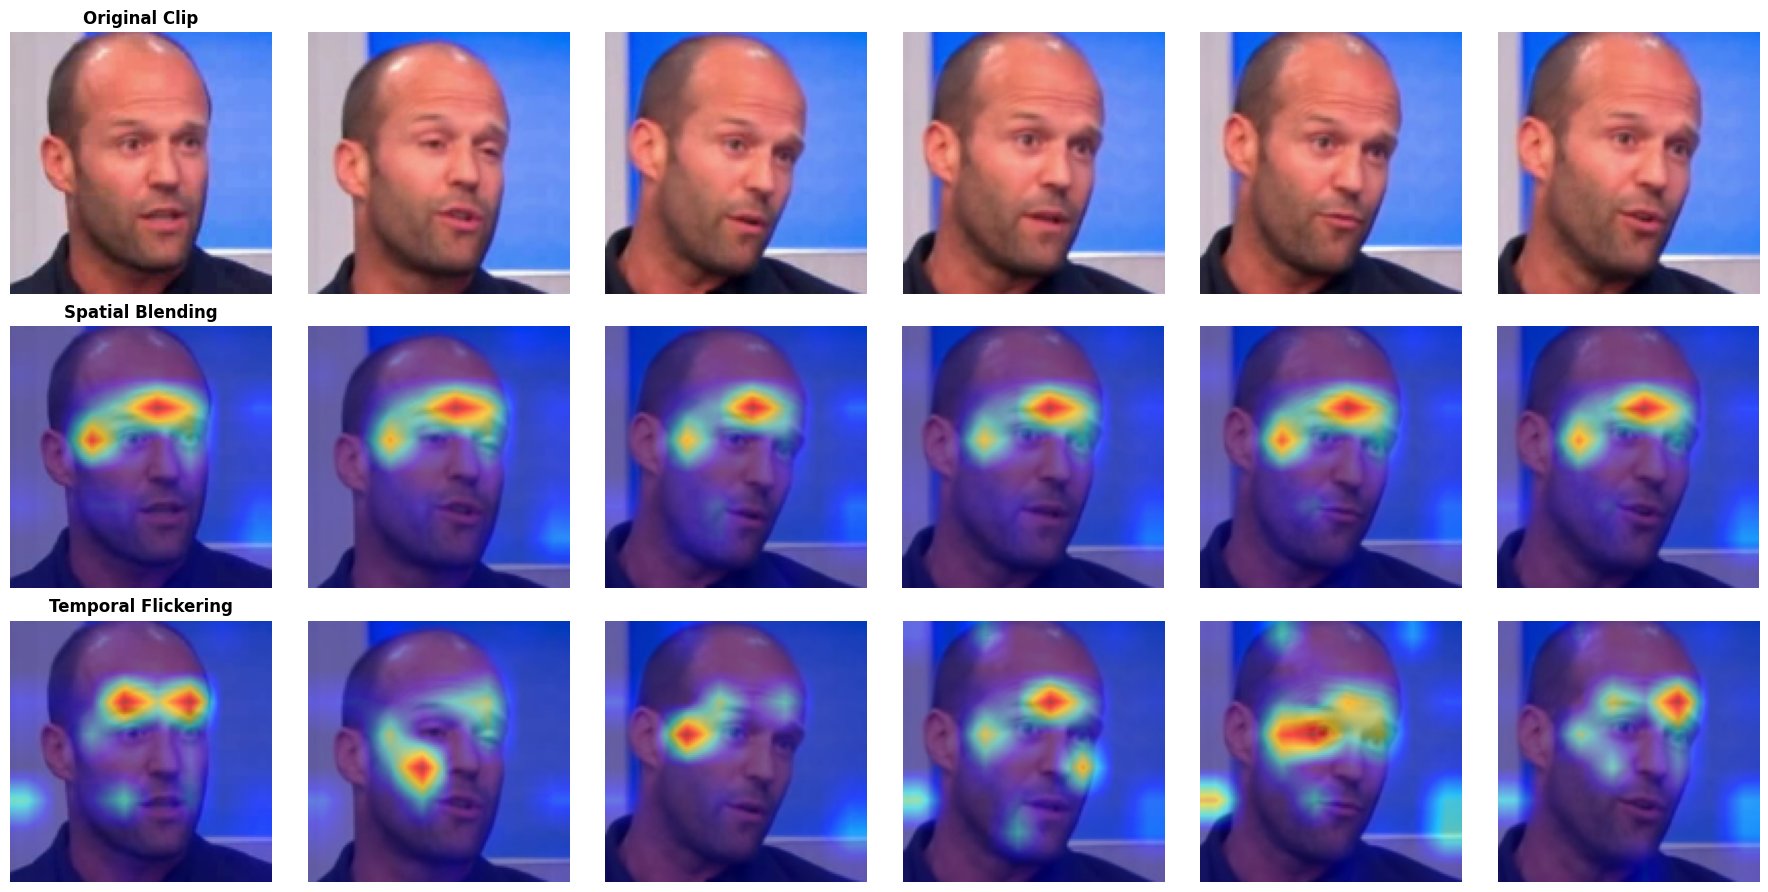

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# 1. Pull a single batch sequence from your existing validation loader
videos, labels = next(iter(val_loader))

# 2. Grab the first Deepfake sequence in the batch
fake_indices = (labels == 1.0).nonzero(as_tuple=True)[0]
if len(fake_indices) == 0:
    idx = 0  # Fallback to first element if no fake in batch
else:
    idx = fake_indices[0]

single_video = videos[idx].unsqueeze(0)

# 3. Generate the interpretation matrices
map_t, map_s = generate_istvt_heatmaps(model, single_video)

# 4. Denormalize and render the visual grid
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
frames = single_video.squeeze(0).cpu()
frames = (frames * std) + mean
frames = torch.clamp(frames, 0, 1).permute(0, 2, 3, 1).numpy()

T = frames.shape[0]
fig, axes = plt.subplots(3, T, figsize=(T * 3, 9))

for i in range(T):
    rgb = (frames[i] * 255).astype(np.uint8)

    t_hm = map_t[0, i]
    s_hm = map_s[0, i]

    t_hm = np.uint8(255 * (t_hm - t_hm.min()) / (t_hm.max() - t_hm.min() + 1e-8))
    s_hm = np.uint8(255 * (s_hm - s_hm.min()) / (s_hm.max() - s_hm.min() + 1e-8))

    t_color = cv2.applyColorMap(t_hm, cv2.COLORMAP_JET)
    s_color = cv2.applyColorMap(s_hm, cv2.COLORMAP_JET)

    t_overlay = cv2.addWeighted(rgb, 0.5, cv2.cvtColor(t_color, cv2.COLOR_BGR2RGB), 0.5, 0)
    s_overlay = cv2.addWeighted(rgb, 0.5, cv2.cvtColor(s_color, cv2.COLOR_BGR2RGB), 0.5, 0)

    axes[0, i].imshow(rgb)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original Clip", fontsize=12, weight='bold')

    axes[1, i].imshow(s_overlay)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Spatial Blending", fontsize=12, weight='bold')

    axes[2, i].imshow(t_overlay)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Temporal Flickering", fontsize=12, weight='bold')

plt.tight_layout()
plt.show()